# MD Case Search — Data Overview

Daily public court filings scraped from [mdcourts.gov](https://www.mdcourts.gov/mdec/publiccases).  
Each row is one case filed the prior business day. This notebook describes the shape and quality of the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
ACCENT   = "#2563EB"   # blue  – has-address
WARN     = "#EF4444"   # red   – no address
NEUTRAL  = "#64748B"   # slate

# ── load ───────────────────────────────────────────────────────────────────
csv_path = sorted(Path("output").glob("cases-*.csv"))[-1]   # most recent file
df = pd.read_csv(csv_path, dtype=str).fillna("")

print(f"Loaded: {csv_path.name}")
print(f"Rows  : {len(df):,}")
print(f"Cols  : {list(df.columns)}")

Loaded: cases-2026-03-28.csv
Rows  : 6,579
Cols  : ['case_number', 'file_date', 'county', 'last_name', 'first_name', 'defendant_name', 'case_type', 'address_street', 'address_city', 'address_state', 'address_zip', 'charges']


## 1. Top-level summary

In [2]:
# Derived helper columns (don't mutate originals)
df["has_address"]  = df["address_street"].str.strip().ne("")
df["has_zip"]      = df["address_zip"].str.strip().ne("")
df["num_charges"]  = df["charges"].apply(lambda x: len(x.split(" | ")) if x.strip() else 0)

n_total      = len(df)
n_with_addr  = df["has_address"].sum()
n_no_addr    = n_total - n_with_addr
n_uniq_names = df["defendant_name"].str.upper().nunique()
n_uniq_case  = df["case_type"].nunique()
n_uniq_cty   = df["county"].nunique()
n_charges    = df["num_charges"].sum()

summary = pd.DataFrame({
    "Metric": [
        "Total cases",
        "Cases with address",
        "Cases missing address",
        "Unique defendant names",
        "Unique case types",
        "Unique counties / courts",
        "Total charges filed",
        "Avg charges per case",
    ],
    "Value": [
        f"{n_total:,}",
        f"{n_with_addr:,}  ({100*n_with_addr/n_total:.1f}%)",
        f"{n_no_addr:,}  ({100*n_no_addr/n_total:.1f}%)",
        f"{n_uniq_names:,}",
        f"{n_uniq_case:,}",
        f"{n_uniq_cty:,}",
        f"{n_charges:,}",
        f"{df['num_charges'].mean():.2f}",
    ],
})

display(summary.style.hide(axis="index")
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

Metric,Value
Total cases,"6,579"
Cases with address,"5,812 (88.3%)"
Cases missing address,767 (11.7%)
Unique defendant names,"3,976"
Unique case types,81
Unique counties / courts,57
Total charges filed,"5,536"
Avg charges per case,0.84


## 2. Address coverage by case type

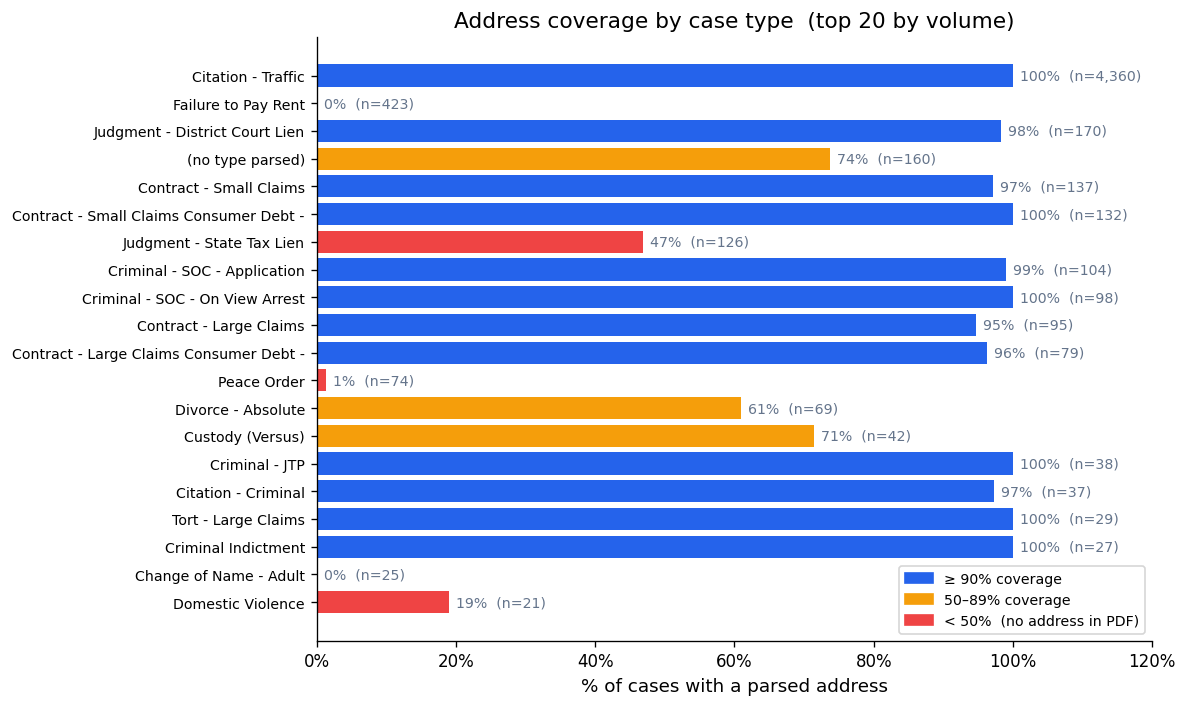

In [3]:
coverage = (
    df.assign(case_type=df["case_type"].replace("", "(no type parsed)"))
    .groupby("case_type")["has_address"]
    .agg(total="count", with_addr="sum")
    .assign(pct=lambda x: 100 * x["with_addr"] / x["total"])
    .sort_values("total", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if p >= 90 else WARN if p < 50 else "#F59E0B" for p in coverage["pct"]]
bars = ax.barh(coverage["case_type"], coverage["pct"], color=colors, edgecolor="none")

# annotate each bar
for bar, total, pct in zip(bars, coverage["total"], coverage["pct"]):
    ax.text(min(pct + 1, 101), bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%  (n={total:,})", va="center", ha="left", fontsize=8.5, color=NEUTRAL)

ax.set_xlim(0, 120)
ax.set_xlabel("% of cases with a parsed address")
ax.set_title("Address coverage by case type  (top 20 by volume)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=8.5)

# legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=ACCENT, label="≥ 90% coverage"),
    Patch(color="#F59E0B", label="50–89% coverage"),
    Patch(color=WARN, label="< 50%  (no address in PDF)"),
], loc="lower right", fontsize=8.5)

plt.tight_layout()
plt.show()

## 3. Records with no address — highlighted sample

In [4]:
no_addr = df[~df["has_address"]].copy()

# Why is the address missing?
NO_ADDR_IN_PDF = {
    "Failure to Pay Rent", "Judgment - State Tax Lien", "Peace Order",
    "Change of Name - Adult", "Change of Name - Minor", "Domestic Violence",
    "Mandamus", "Appeal of Civil Case", "Appeal of Criminal Case",
    "Judgment - Federal Lien", "Authorization for Specific Transaction",
    "Guardianship - Adult Person and Property", "Guardianship - Adult Person",
    "Guardianship - Minor Person", "Domestic Violence - Child Abuse",
    "Independent Proceedings - Deposition",
}

def reason(row):
    ct = row["case_type"]
    if ct in NO_ADDR_IN_PDF:
        return "Not published in PDF"
    if ct == "":
        return "Case type parse failure"
    return "Address block absent / parse edge case"

no_addr["reason"] = no_addr.apply(reason, axis=1)

# Reason breakdown
reason_counts = no_addr["reason"].value_counts().reset_index()
reason_counts.columns = ["Reason", "Count"]
reason_counts["Pct of all no-address"] = (
    100 * reason_counts["Count"] / len(no_addr)
).map("{:.1f}%".format)
print(f"Total cases with no address: {len(no_addr):,}\n")
display(reason_counts.style.hide(axis="index"))

print(f"\nSample — first 15 missing-address records:")
display(
    no_addr[["case_number", "file_date", "county", "defendant_name",
             "case_type", "charges", "reason"]]
    .head(15)
    .style.hide(axis="index")
    .apply(lambda col: ["background-color: #FEE2E2"] * len(col)
           if col.name == "reason" else [""] * len(col), axis=0)
    .set_properties(**{"font-size": "11px"})
)

Total cases with no address: 767



Reason,Count,Pct of all no-address
Not published in PDF,657,85.7%
Address block absent / parse edge case,68,8.9%
Case type parse failure,42,5.5%



Sample — first 15 missing-address records:


case_number,file_date,county,defendant_name,case_type,charges,reason
D-121-CV-26-813932,03/27/2026,Allegany,CHRISTINA MOORE v. TAMARA BOYD,Peace Order,,Not published in PDF
D-121-CV-26-813933,03/27/2026,Allegany,AMANDA BEEBE v. TAMARA BOYD,Peace Order,,Not published in PDF
C-01-JG-26-000138,03/27/2026,Allegany Circuit Court,"Comptroller of Maryland - Annapolis vs. Lorraine Bryant, et al.",Judgment - State Tax Lien,,Not published in PDF
C-01-JG-26-000139,03/27/2026,Allegany Circuit Court,Comptroller of Maryland - Annapolis vs. Connie Brown,Judgment - State Tax Lien,,Not published in PDF
D-07-CV-26-813873,03/27/2026,Annapolis,OYOMA AKEMU v. MICHAEL JONES,Peace Order,,Not published in PDF
D-07-CV-26-813955,03/27/2026,Annapolis,ALINA BOYKO v. AVINASH RAO,Peace Order,,Not published in PDF
C-02-FM-26-001012,03/27/2026,Anne Arundel Circuit Court,In the Matter of Pamela Ann McCormick,Change of Name - Adult,,Not published in PDF
C-02-FM-26-001013,03/27/2026,Anne Arundel Circuit Court,In the Matter of Christopher Kim,Foreign Guardianship,,Address block absent / parse edge case
C-02-FM-26-001016,03/27/2026,Anne Arundel Circuit Court,Alicia Dwarica vs. Damian Textus,Divorce - Absolute,,Address block absent / parse edge case
C-02-FM-26-001018,03/27/2026,Anne Arundel Circuit Court,Michelle Caniglia vs. Jason Davis,Divorce - Absolute,,Address block absent / parse edge case


## 4. Unique values — key variables

In [5]:
# ── 4a. Case types ────────────────────────────────────────────────────────
ct = (df["case_type"].replace("", "(no type)")
      .value_counts()
      .reset_index()
      .rename(columns={"case_type": "Case Type", "count": "Count"}))
ct["% of total"] = (100 * ct["Count"] / len(df)).map("{:.1f}%".format)

print(f"Unique case types: {df['case_type'].replace('','(no type)').nunique()}\n")
display(ct.style.hide(axis="index").bar(subset=["Count"], color=ACCENT, width=60))

Unique case types: 81



Case Type,Count,% of total
Citation - Traffic,4360,66.3%
Failure to Pay Rent,423,6.4%
Judgment - District Court Lien,170,2.6%
(no type),160,2.4%
Contract - Small Claims,137,2.1%
Contract - Small Claims Consumer Debt -,132,2.0%
Judgment - State Tax Lien,126,1.9%
Criminal - SOC - Application,104,1.6%
Criminal - SOC - On View Arrest,98,1.5%
Contract - Large Claims,95,1.4%


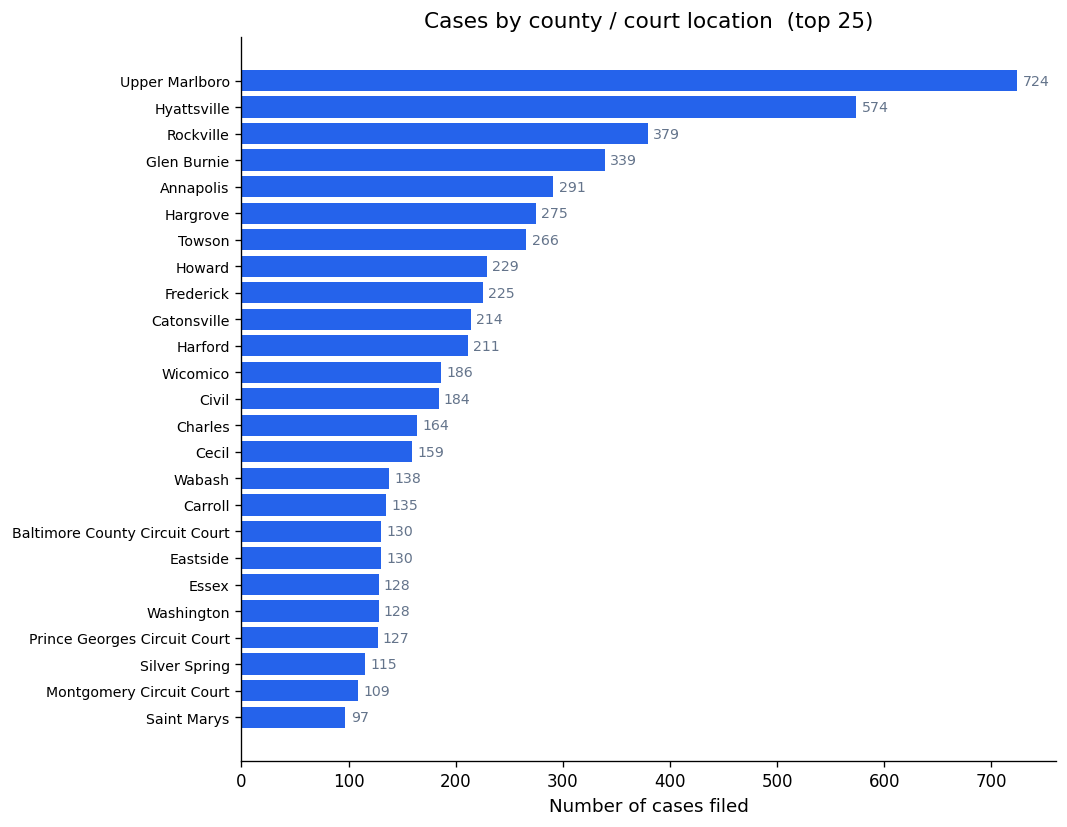


Unique counties / courts: 57


In [6]:
# ── 4b. Counties / court locations ────────────────────────────────────────
cty = (df["county"].replace("", "(unknown)")
       .value_counts()
       .head(25)
       .reset_index()
       .rename(columns={"county": "County / Court", "count": "Count"}))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(cty["County / Court"], cty["Count"], color=ACCENT, edgecolor="none")
for i, (count, name) in enumerate(zip(cty["Count"], cty["County / Court"])):
    ax.text(count + 5, i, f"{count:,}", va="center", fontsize=8.5, color=NEUTRAL)
ax.invert_yaxis()
ax.set_xlabel("Number of cases filed")
ax.set_title("Cases by county / court location  (top 25)")
ax.tick_params(axis="y", labelsize=8.5)
plt.tight_layout()
plt.show()

print(f"\nUnique counties / courts: {df['county'].replace('','(unknown)').nunique()}")

In [7]:
# ── 4c. Defendant states (where do defendants live?) ─────────────────────
state_counts = (df[df["address_state"].ne("")]
                ["address_state"]
                .value_counts()
                .reset_index()
                .rename(columns={"address_state": "State", "count": "Count"}))
state_counts["% of addressed cases"] = (
    100 * state_counts["Count"] / n_with_addr
).map("{:.1f}%".format)

print(f"Unique defendant states: {state_counts['State'].nunique()}\n")
display(
    state_counts.head(20)
    .style.hide(axis="index")
    .bar(subset=["Count"], color=ACCENT, width=60)
)

Unique defendant states: 32



State,Count,% of addressed cases
MD,5082,87.4%
VA,139,2.4%
DC,135,2.3%
PA,129,2.2%
DE,50,0.9%
WV,49,0.8%
NY,46,0.8%
NJ,37,0.6%
NC,35,0.6%
TX,20,0.3%


In [8]:
# ── 4d. Repeat defendants ─────────────────────────────────────────────────
name_counts = (df["defendant_name"].str.upper().str.strip()
               .value_counts()
               .reset_index()
               .rename(columns={"defendant_name": "Defendant Name", "count": "Cases today"}))

appears_once  = (name_counts["Cases today"] == 1).sum()
appears_multi = (name_counts["Cases today"] > 1).sum()

print(f"Total distinct defendant names : {len(name_counts):,}")
print(f"  Appear exactly once          : {appears_once:,}  ({100*appears_once/len(name_counts):.1f}%)")
print(f"  Appear 2+ times today        : {appears_multi:,}  ({100*appears_multi/len(name_counts):.1f}%)")
print()
print("Top 15 defendants by case count today:")
display(
    name_counts.head(15)
    .style.hide(axis="index")
    .bar(subset=["Cases today"], color="#7C3AED", width=60)
)

Total distinct defendant names : 3,976
  Appear exactly once          : 3,126  (78.6%)
  Appear 2+ times today        : 850  (21.4%)

Top 15 defendants by case count today:


Defendant Name,Cases today
"MAYO, TITUS ZING",27
HOUSING AUTHORITY OF PRINCE GEORGE`S COUNTY -,25
"VELOCITY INVESTMENTS, LLC ASSIGNEE OF LENDINGCLUB CORPORATION CONTRACT - LARGE CLAIMS",22
"CAPITAL ONE, N.A., SUCCESSOR BY MERGER TO DISCOVER",16
"PITT, BRITTANY MARIE",16
"DAVIS, KYREE",15
"ELLISON, DENNIS MARCO",14
"THOMPSON, KEVIN DAVID",14
"ANATAMEY, NATHAN JAMES",14
"HILL, KHYRAH J.",14


## 5. Charges breakdown

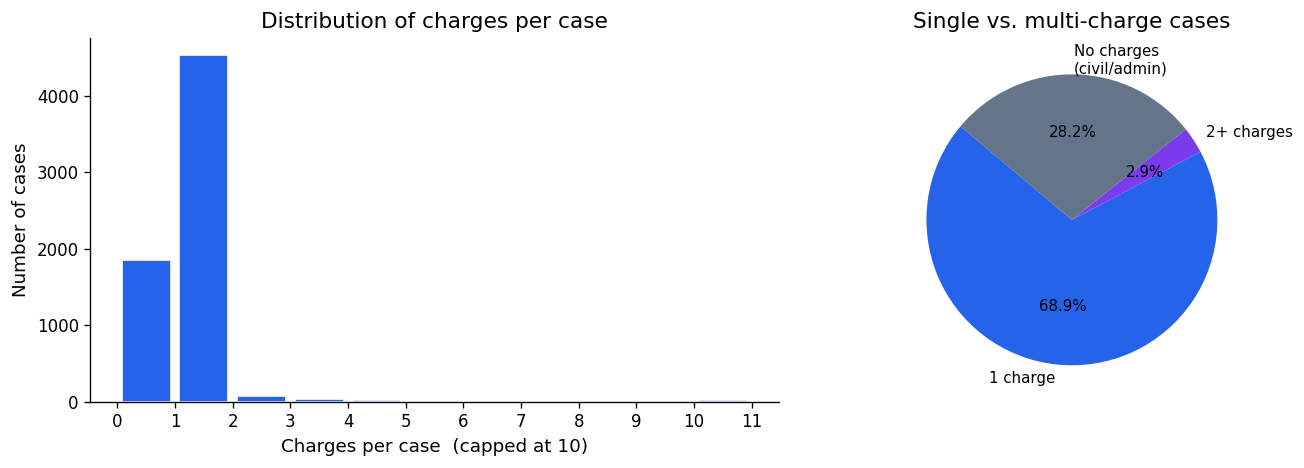


Unique individual charge texts: 1,512

Top 20 most common charges:


Charge,Count
TO,2153
ON,1974
DRIVING,1826
VEHICLE,1730
OF,1294
AND,1234
HIGHWAY,1187
FAILURE,1139
MPH,1084
IN,1082


In [9]:
# Charges per case distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of charges per case (capped at 10 for readability)
charge_dist = df["num_charges"].clip(upper=10)
bins = range(0, 12)
axes[0].hist(charge_dist, bins=bins, color=ACCENT, edgecolor="white", rwidth=0.85)
axes[0].set_xlabel("Charges per case  (capped at 10)")
axes[0].set_ylabel("Number of cases")
axes[0].set_title("Distribution of charges per case")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Right: pie — cases with 1 charge vs 2+ vs 0
zero = (df["num_charges"] == 0).sum()
one  = (df["num_charges"] == 1).sum()
multi = (df["num_charges"] >= 2).sum()
axes[1].pie([one, multi, zero],
            labels=["1 charge", "2+ charges", "No charges\n(civil/admin)"],
            colors=[ACCENT, "#7C3AED", NEUTRAL],
            autopct="%1.1f%%", startangle=140, textprops={"fontsize": 9})
axes[1].set_title("Single vs. multi-charge cases")

plt.tight_layout()
plt.show()

# Most common individual charge texts
all_charges = (
    df["charges"]
    .dropna()
    .str.split(" | ")
    .explode()
    .str.strip()
    .loc[lambda s: s.ne("")]
)
top_charges = (all_charges.value_counts()
               .head(20)
               .reset_index()
               .rename(columns={"charges": "Charge", "count": "Count"}))
print(f"\nUnique individual charge texts: {all_charges.nunique():,}")
print(f"\nTop 20 most common charges:")
display(top_charges.style.hide(axis="index").bar(subset=["Count"], color="#7C3AED", width=60))

## 6. Field completeness heatmap

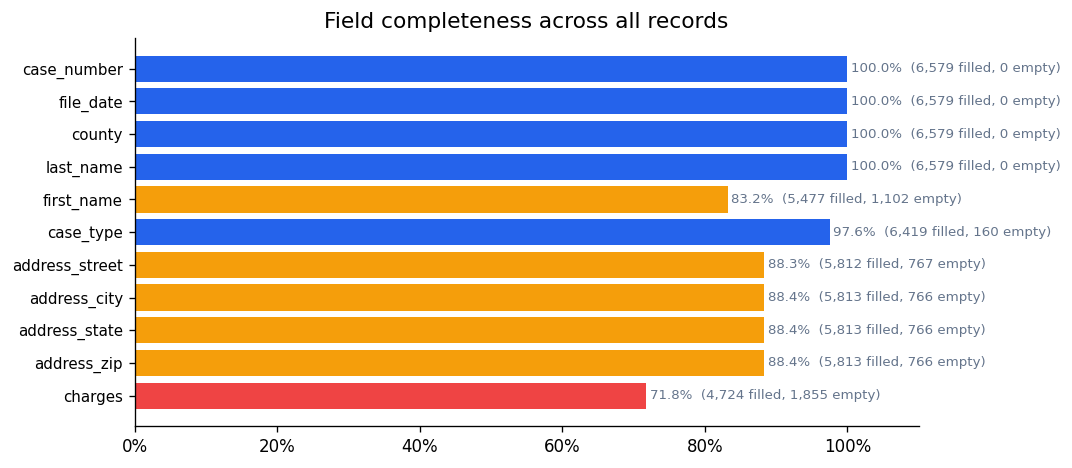

In [10]:
fields = ["case_number", "file_date", "county", "last_name", "first_name",
          "case_type", "address_street", "address_city", "address_state",
          "address_zip", "charges"]

completeness = pd.DataFrame({
    "Field": fields,
    "Filled": [df[f].str.strip().ne("").sum() for f in fields],
    "Empty":  [df[f].str.strip().eq("").sum() for f in fields],
})
completeness["Fill %"] = 100 * completeness["Filled"] / len(df)

fig, ax = plt.subplots(figsize=(9, 4))
y = range(len(fields))
ax.barh(y, completeness["Fill %"], color=[ACCENT if p > 95 else "#F59E0B" if p > 80 else WARN
                                           for p in completeness["Fill %"]], edgecolor="none")
ax.set_yticks(list(y))
ax.set_yticklabels(fields, fontsize=9)
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Field completeness across all records")
for i, (pct, filled, empty) in enumerate(zip(completeness["Fill %"], completeness["Filled"], completeness["Empty"])):
    ax.text(pct + 0.5, i, f"{pct:.1f}%  ({filled:,} filled, {empty:,} empty)",
            va="center", fontsize=8, color=NEUTRAL)
ax.invert_yaxis()
plt.tight_layout()
plt.show()